In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np

save_path = '/content/drive/MyDrive/road_data_numpy'

X_train = np.load(f'{save_path}/X_train.npy')
y_train = np.load(f'{save_path}/y_train.npy')
X_val   = np.load(f'{save_path}/X_val.npy')
y_val   = np.load(f'{save_path}/y_val.npy')
X_test  = np.load(f'{save_path}/X_test.npy')
y_test  = np.load(f'{save_path}/y_test.npy')

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

X_train: (460, 20, 64, 64, 3), y_train: (460,)
X_val:   (100, 20, 64, 64, 3),   y_val:   (100,)
X_test:  (100, 20, 64, 64, 3),  y_test:  (100,)


In [ ]:
import os
import cv2
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    ConvLSTM2D, BatchNormalization, Dense, Flatten, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# ── Parametri ─────────────────────────────────────────────────
IMAGE_HEIGHT, IMAGE_WIDTH = 64, 64
SEQUENCE_LENGTH = 20
DATASET_DIR     = '/content/drive/MyDrive/road_data'
CLASSES_LIST    = ['normal', 'damage']  # 0=normal, 1=damage

print("Importi uspješni.")

Importi uspješni.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print("Class weights:", class_weight_dict)

Class weights: {np.int32(0): np.float64(1.0), np.int32(1): np.float64(1.0)}


In [ ]:
import gc
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, TimeDistributed, GlobalAveragePooling2D, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, roc_auc_score
import os

os.makedirs('/content/drive/MyDrive/models_mobile', exist_ok=True)
tf.keras.backend.clear_session()
gc.collect()

name        = "SGD"
lr          = 1e-3
bs          = 8
lstm_units  = 64
dense_units = 32

base_model = MobileNetV2(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs  = Input(shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3))
x       = TimeDistributed(base_model)(inputs)
x       = TimeDistributed(GlobalAveragePooling2D())(x)
x       = LSTM(lstm_units, return_sequences=False)(x)
x       = BatchNormalization()(x)
x       = Dropout(0.5)(x)
x       = Dense(dense_units, activation='relu')(x)
x       = Dropout(0.4)(x)
outputs = Dense(1, activation='sigmoid')(x)

model_mobile = Model(inputs, outputs)
model_mobile.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)

history = model_mobile.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=bs,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

test_loss, test_acc = model_mobile.evaluate(X_test, y_test, verbose=0)
y_proba = model_mobile.predict(X_test, verbose=0).flatten()
y_pred  = (y_proba >= 0.5).astype(int)
auc     = roc_auc_score(y_test, y_proba)

print(f"\n  Test Acc : {test_acc:.4f}")
print(f"  ROC-AUC  : {auc:.4f}")
print(f"  Epohe    : {len(history.history['loss'])}")
print(classification_report(y_test, y_pred, target_names=CLASSES_LIST))

model_mobile.save('/content/drive/MyDrive/models_mobile/SGD_model.keras')
np.save('/content/drive/MyDrive/models_mobile/SGD_y_proba.npy', y_proba)
print("Sačuvano!")

/tmp/ipykernel_394/542113299.py:19: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 111s 566ms/step - accuracy: 0.7261 - loss: 0.5718 - val_accuracy: 0.9100 - val_loss: 0.4572
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - accuracy: 0.8435 - loss: 0.3806 - val_accuracy: 0.9300 - val_loss: 0.3027
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 107ms/step - accuracy: 0.9000 - loss: 0.2759 - val_accuracy: 0.9300 - val_loss: 0.2459
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.9087 - loss: 0.2540 - val_accuracy: 0.9500 - val_loss: 0.1915
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.9239 - loss: 0.2351 - val_accuracy: 0.9500 - val_loss: 0.1806
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - accuracy: 0.9261 - loss: 0.1970 - val_accuracy: 0.9300 - val_loss: 0.1652
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.9174 - loss: 0.2165 - val_accuracy: 0.9400 - val_loss: 0.1549
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step -

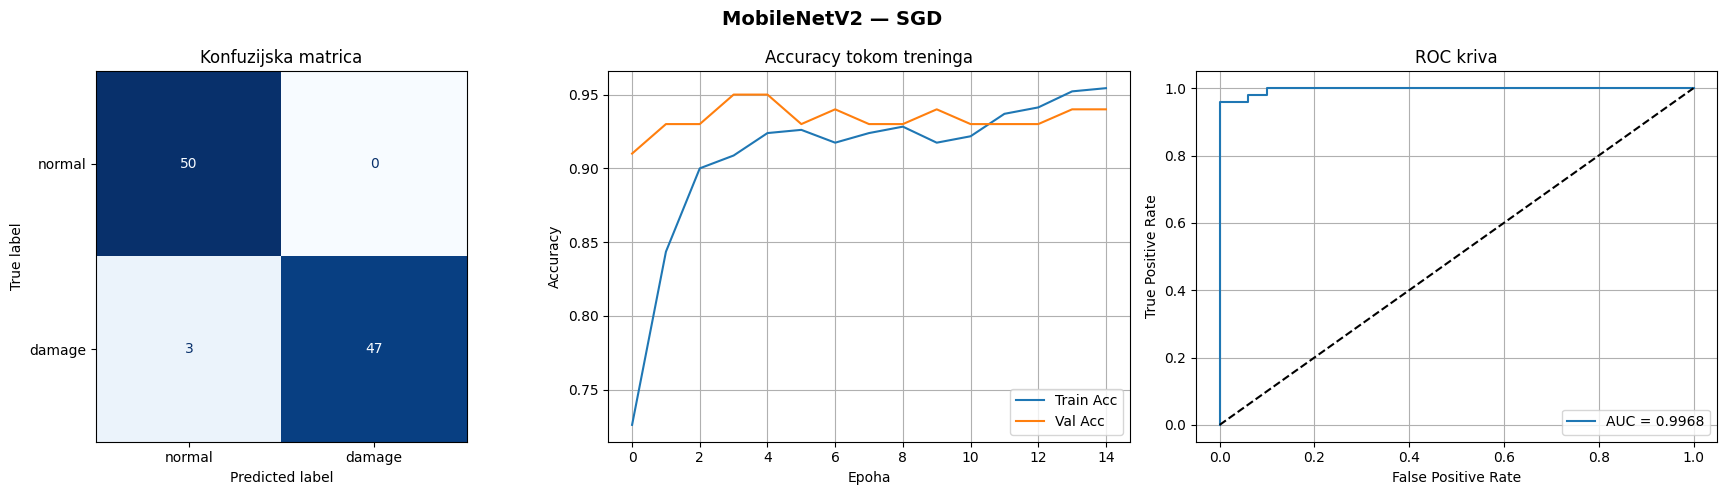

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

y_proba = np.load('/content/drive/MyDrive/models_mobile/SGD_y_proba.npy')
y_pred  = (y_proba >= 0.5).astype(int)
auc     = roc_auc_score(y_test, y_proba)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("MobileNetV2 — SGD", fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES_LIST)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Konfuzijska matrica")

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title("Accuracy tokom treninga")
axes[1].set_xlabel("Epoha")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_title("ROC kriva")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
tf.keras.backend.clear_session()
gc.collect()

name        = "RMSprop"
lr          = 1e-3
bs          = 8
lstm_units  = 64
dense_units = 32

base_model = MobileNetV2(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs  = Input(shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3))
x       = TimeDistributed(base_model)(inputs)
x       = TimeDistributed(GlobalAveragePooling2D())(x)
x       = LSTM(lstm_units, return_sequences=False)(x)
x       = BatchNormalization()(x)
x       = Dropout(0.5)(x)
x       = Dense(dense_units, activation='relu')(x)
x       = Dropout(0.4)(x)
outputs = Dense(1, activation='sigmoid')(x)

model_mobile = Model(inputs, outputs)
model_mobile.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=lr),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)

history = model_mobile.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=bs,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

test_loss, test_acc = model_mobile.evaluate(X_test, y_test, verbose=0)
y_proba = model_mobile.predict(X_test, verbose=0).flatten()
y_pred  = (y_proba >= 0.5).astype(int)
auc     = roc_auc_score(y_test, y_proba)

print(f"\n  Test Acc : {test_acc:.4f}")
print(f"  ROC-AUC  : {auc:.4f}")
print(f"  Epohe    : {len(history.history['loss'])}")
print(classification_report(y_test, y_pred, target_names=CLASSES_LIST))

model_mobile.save('/content/drive/MyDrive/models_mobile/RMSprop_model.keras')
np.save('/content/drive/MyDrive/models_mobile/RMSprop_y_proba.npy', y_proba)
print("Sačuvano!")

/tmp/ipykernel_394/1322602370.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3), include_top=False, weights='imagenet')


Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 106s 536ms/step - accuracy: 0.8217 - loss: 0.4227 - val_accuracy: 0.9200 - val_loss: 0.2400
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 140ms/step - accuracy: 0.8978 - loss: 0.2603 - val_accuracy: 0.9400 - val_loss: 0.1829
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.9065 - loss: 0.2764 - val_accuracy: 0.9700 - val_loss: 0.1305
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.9065 - loss: 0.2238 - val_accuracy: 0.9700 - val_loss: 0.0818
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.9478 - loss: 0.1249 - val_accuracy: 0.9600 - val_loss: 0.1020
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy: 0.9391 - loss: 0.2097 - val_accuracy: 0.9600 - val_loss: 0.1029
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.9261 - loss: 0.2144 - val_accuracy: 0.9600 - val_loss: 0.0673
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy: 0.9413 - loss: 0.1891 - val_accuracy: 

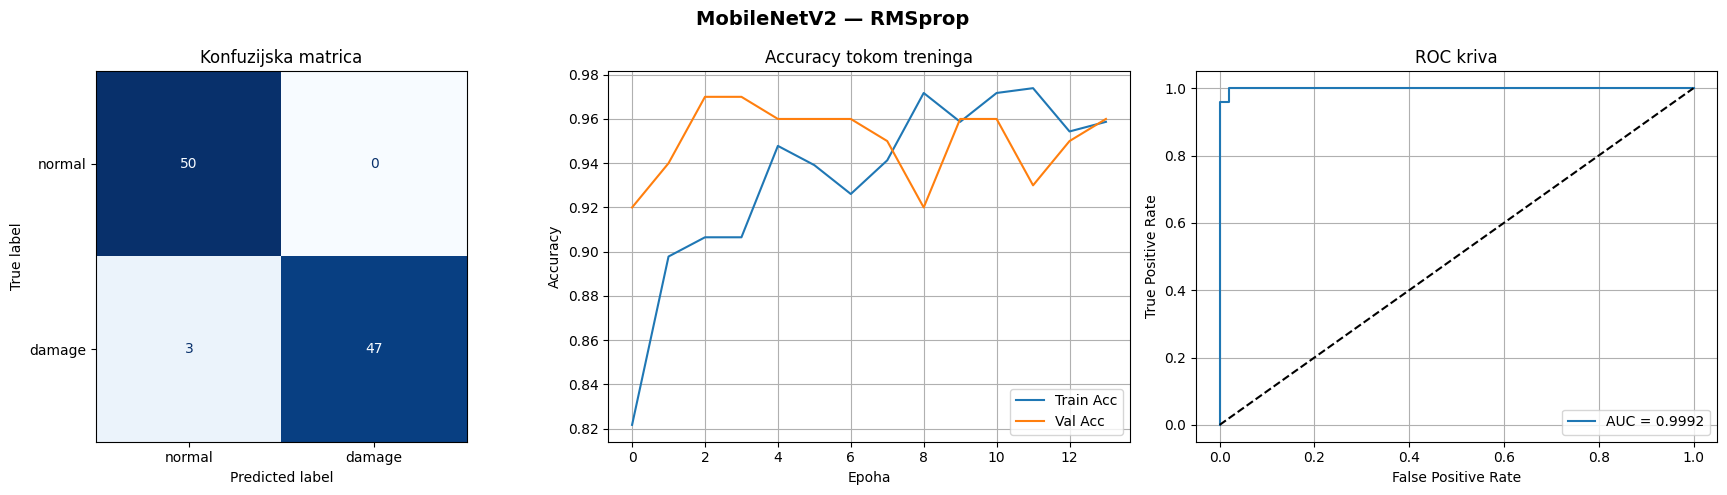

In [ ]:
y_proba = np.load('/content/drive/MyDrive/models_mobile/RMSprop_y_proba.npy')
y_pred  = (y_proba >= 0.5).astype(int)
auc     = roc_auc_score(y_test, y_proba)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("MobileNetV2 — RMSprop", fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES_LIST)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Konfuzijska matrica")

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title("Accuracy tokom treninga")
axes[1].set_xlabel("Epoha")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_title("ROC kriva")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
tf.keras.backend.clear_session()
gc.collect()

name        = "relu activation"
lr          = 1e-4
bs          = 8
lstm_units  = 64
dense_units = 32

base_model = MobileNetV2(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs  = Input(shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3))
x       = TimeDistributed(base_model)(inputs)
x       = TimeDistributed(GlobalAveragePooling2D())(x)
x       = LSTM(lstm_units, return_sequences=False)(x)
x       = BatchNormalization()(x)
x       = Dropout(0.5)(x)
x       = Dense(dense_units, activation='relu')(x)
x       = Dropout(0.4)(x)
outputs = Dense(1, activation='sigmoid')(x)

model_mobile = Model(inputs, outputs)
model_mobile.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)

history = model_mobile.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=bs,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

test_loss, test_acc = model_mobile.evaluate(X_test, y_test, verbose=0)
y_proba = model_mobile.predict(X_test, verbose=0).flatten()
y_pred  = (y_proba >= 0.5).astype(int)
auc     = roc_auc_score(y_test, y_proba)

print(f"\n  Test Acc : {test_acc:.4f}")
print(f"  ROC-AUC  : {auc:.4f}")
print(f"  Epohe    : {len(history.history['loss'])}")
print(classification_report(y_test, y_pred, target_names=CLASSES_LIST))

model_mobile.save('/content/drive/MyDrive/models_mobile/relu_activation_model.keras')
np.save('/content/drive/MyDrive/models_mobile/relu_activation_y_proba.npy', y_proba)
print("Sačuvano!")

/tmp/ipykernel_394/3506484561.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3), include_top=False, weights='imagenet')


Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 109s 583ms/step - accuracy: 0.6130 - loss: 0.8594 - val_accuracy: 0.8500 - val_loss: 0.5210
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 130ms/step - accuracy: 0.7435 - loss: 0.5706 - val_accuracy: 0.8900 - val_loss: 0.4245
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.8065 - loss: 0.4136 - val_accuracy: 0.9200 - val_loss: 0.3224
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - accuracy: 0.8370 - loss: 0.4003 - val_accuracy: 0.9100 - val_loss: 0.2818
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.8565 - loss: 0.3423 - val_accuracy: 0.9200 - val_loss: 0.2459
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.8630 - loss: 0.2870 - val_accuracy: 0.9100 - val_loss: 0.2091
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.9087 - loss: 0.2593 - val_accuracy: 0.9300 - val_loss: 0.1764
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - accuracy: 0.8978 - loss: 0.2307 - val_accuracy:


  Test Acc : 0.9700
  ROC-AUC  : 0.9980
  Epohe    : 28
              precision    recall  f1-score   support

      normal       0.94      1.00      0.97        50
      damage       1.00      0.94      0.97        50

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100

Sačuvano!


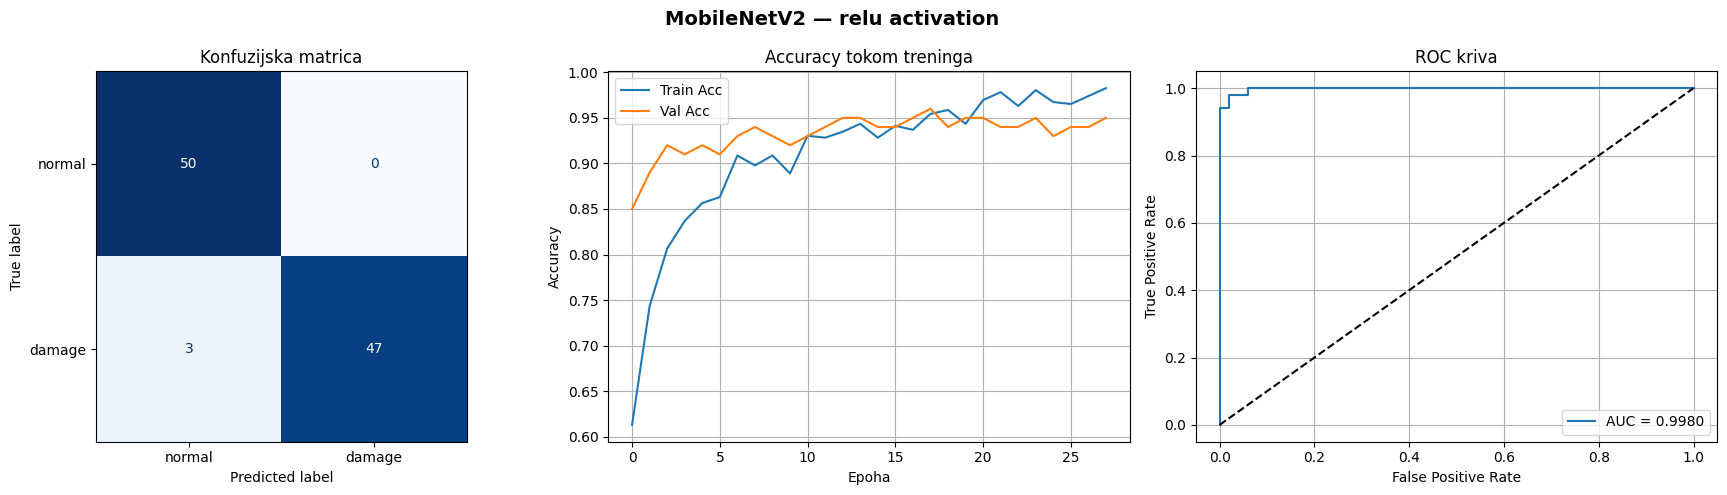

In [ ]:
y_proba = np.load('/content/drive/MyDrive/models_mobile/relu_activation_y_proba.npy')
y_pred  = (y_proba >= 0.5).astype(int)
auc     = roc_auc_score(y_test, y_proba)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("MobileNetV2 — relu activation", fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES_LIST)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Konfuzijska matrica")

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title("Accuracy tokom treninga")
axes[1].set_xlabel("Epoha")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_title("ROC kriva")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ── Težine klasa ──────────────────────────────────────────────
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}
print(f"Težine klasa: {class_weight_dict}")

# ── Model ─────────────────────────────────────────────────────
model = Sequential([
    ConvLSTM2D(
        filters=32,              # povećano 16->32
        kernel_size=(3, 3),
        activation='tanh',
        input_shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3),
        return_sequences=False,
        padding='same'
    ),
    BatchNormalization(),
    Flatten(),
    Dense(64, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(0.01)),  # smanjena regularizacija 0.05->0.01
    BatchNormalization(),
    Dropout(0.4),                # smanjen dropout 0.6->0.4
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # smanjen lr 1e-3->1e-4
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Težine klasa: {0: np.float64(1.0), 1: np.float64(1.0)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 64, 64, 32)     │        40,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     8,388,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,429,569 (32.16 MB)

 Trainable params: 8,429,377 (32.16 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,                 # povećano 10->15
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

print("[INFO] Počinjem treniranje...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,               # povećano 8->16
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr]
)

[INFO] Počinjem treniranje...
Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 409ms/step - accuracy: 0.9304 - loss: 1.4571 - val_accuracy: 0.5000 - val_loss: 3.6137 - learning_rate: 1.0000e-04
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 218ms/step - accuracy: 0.9543 - loss: 1.3223 - val_accuracy: 0.5000 - val_loss: 2.7169 - learning_rate: 1.0000e-04
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 220ms/step - accuracy: 0.9587 - loss: 1.2073 - val_accuracy: 0.5000 - val_loss: 1.7968 - learning_rate: 1.0000e-04
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step - accuracy: 0.9783 - loss: 1.0809 - val_accuracy: 0.9000 - val_loss: 1.4680 - learning_rate: 1.0000e-04
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step - accuracy: 0.9891 - loss: 0.9678 - val_accuracy: 0.9500 - val_loss: 1.3705 - learning_rate: 1.0000e-04
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 208ms/step - accuracy: 0.9761 - loss: 0.9240 - val_accuracy: 0.5000 - val_loss: 1.4838 - learning_rate: 1.0000e-04
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
y_proba = model.predict(X_test, verbose=0).flatten()
y_pred  = (y_proba >= 0.5).astype(int)
auc     = roc_auc_score(y_test, y_proba)

print(f"  Test Acc : {test_acc:.4f}")
print(f"  ROC-AUC  : {auc:.4f}")
print(classification_report(y_test, y_pred, target_names=CLASSES_LIST))

  Test Acc : 0.9200
  ROC-AUC  : 0.9780
              precision    recall  f1-score   support

      normal       0.86      1.00      0.93        50
      damage       1.00      0.84      0.91        50

    accuracy                           0.92       100
   macro avg       0.93      0.92      0.92       100
weighted avg       0.93      0.92      0.92       100



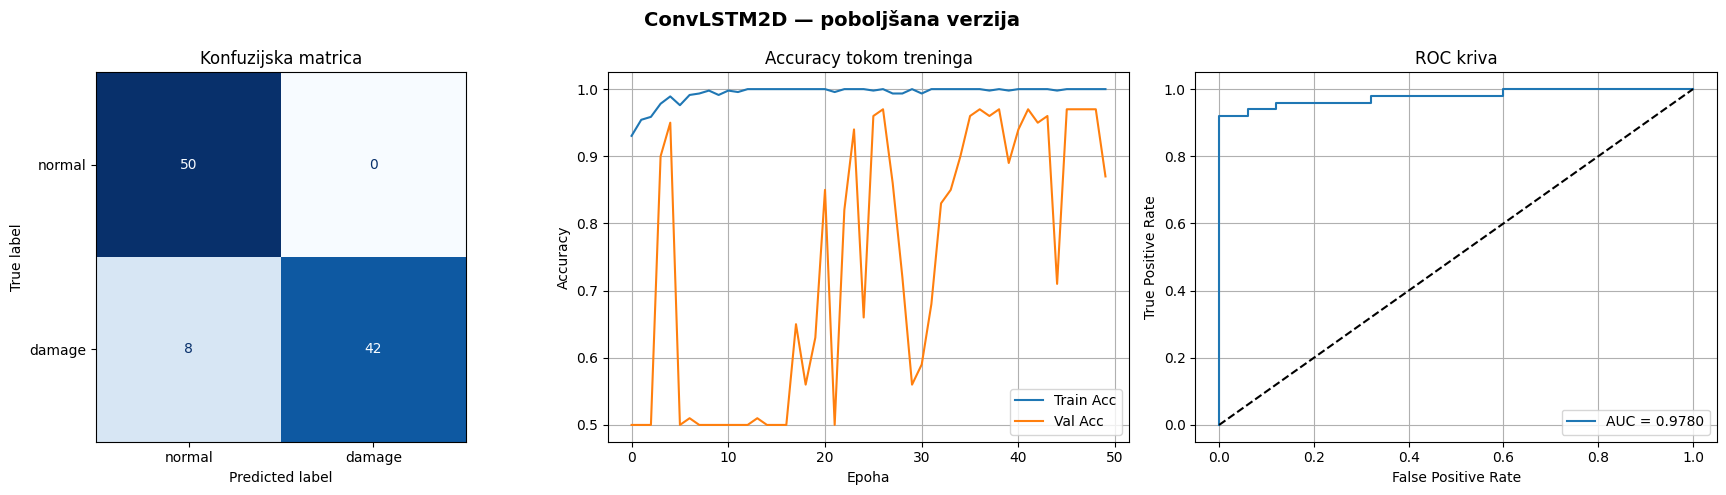

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ConvLSTM2D — poboljšana verzija", fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES_LIST)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Konfuzijska matrica")

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title("Accuracy tokom treninga")
axes[1].set_xlabel("Epoha")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_title("ROC kriva")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Kombinuj train + val
X_all = np.concatenate([X_train, X_val], axis=0)
y_all = np.concatenate([y_train, y_val], axis=0)

# Novi split 80/20
X_tr, X_v, y_tr, y_v = train_test_split(
    X_all, y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=42
)

print(f"X_tr: {X_tr.shape}, y_tr: {y_tr.shape}")
print(f"X_v:  {X_v.shape},  y_v:  {y_v.shape}")

# Snimi kao novi dataset
save_path_new = '/content/drive/MyDrive/road_data_numpy_v2'
os.makedirs(save_path_new, exist_ok=True)

np.save(f'{save_path_new}/X_train.npy', X_tr)
np.save(f'{save_path_new}/y_train.npy', y_tr)
np.save(f'{save_path_new}/X_val.npy',   X_v)
np.save(f'{save_path_new}/y_val.npy',   y_v)

print("Sačuvano u road_data_numpy_v2!")

X_tr: (448, 20, 64, 64, 3), y_tr: (448,)
X_v:  (112, 20, 64, 64, 3),  y_v:  (112,)
Sačuvano u road_data_numpy_v2!


In [ ]:
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Dense, Flatten, Dropout, MaxPooling3D

tf.keras.backend.clear_session()
gc.collect()

model = Sequential([
    ConvLSTM2D(
        filters=32,
        kernel_size=(3, 3),
        activation='tanh',
        input_shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3),
        return_sequences=True,   # mora biti True da MaxPooling3D može raditi
        padding='same'
    ),
    MaxPooling3D(pool_size=(1, 2, 2)),  # smanjuje prostornu dimenziju 64x64 -> 32x32
    BatchNormalization(),
    ConvLSTM2D(
        filters=16,
        kernel_size=(3, 3),
        activation='tanh',
        return_sequences=False,
        padding='same'
    ),
    BatchNormalization(),
    Flatten(),
    Dense(64, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 20, 64, 64, 32) │        40,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 20, 32, 32, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 32, 32, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 32, 32, 16)     │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,048,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,117,313 (4.26 MB)

 Trainable params: 1,117,089 (4.26 MB)

 Non-trainable params: 224 (896.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr]
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
y_proba = model.predict(X_test, verbose=0).flatten()
y_pred  = (y_proba >= 0.5).astype(int)
auc     = roc_auc_score(y_test, y_proba)

print(f"\n  Test Acc : {test_acc:.4f}")
print(f"  ROC-AUC  : {auc:.4f}")
print(f"  Epohe    : {len(history.history['loss'])}")
print(classification_report(y_test, y_pred, target_names=CLASSES_LIST))

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 591ms/step - accuracy: 0.9326 - loss: 1.4364 - val_accuracy: 0.6500 - val_loss: 1.8137 - learning_rate: 1.0000e-04
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 294ms/step - accuracy: 0.9609 - loss: 1.3252 - val_accuracy: 0.5000 - val_loss: 1.9289 - learning_rate: 1.0000e-04
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 288ms/step - accuracy: 0.9565 - loss: 1.2179 - val_accuracy: 0.5000 - val_loss: 2.0564 - learning_rate: 1.0000e-04
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 282ms/step - accuracy: 0.9674 - loss: 1.1474 - val_accuracy: 0.5000 - val_loss: 2.1190 - learning_rate: 1.0000e-04
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 280ms/step - accuracy: 0.9891 - loss: 1.0566 - val_accuracy: 0.5000 - val_loss: 2.0452 - learning_rate: 1.0000e-04
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.9877 - loss: 1.0158
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 269ms/step - accuracy: 0.98

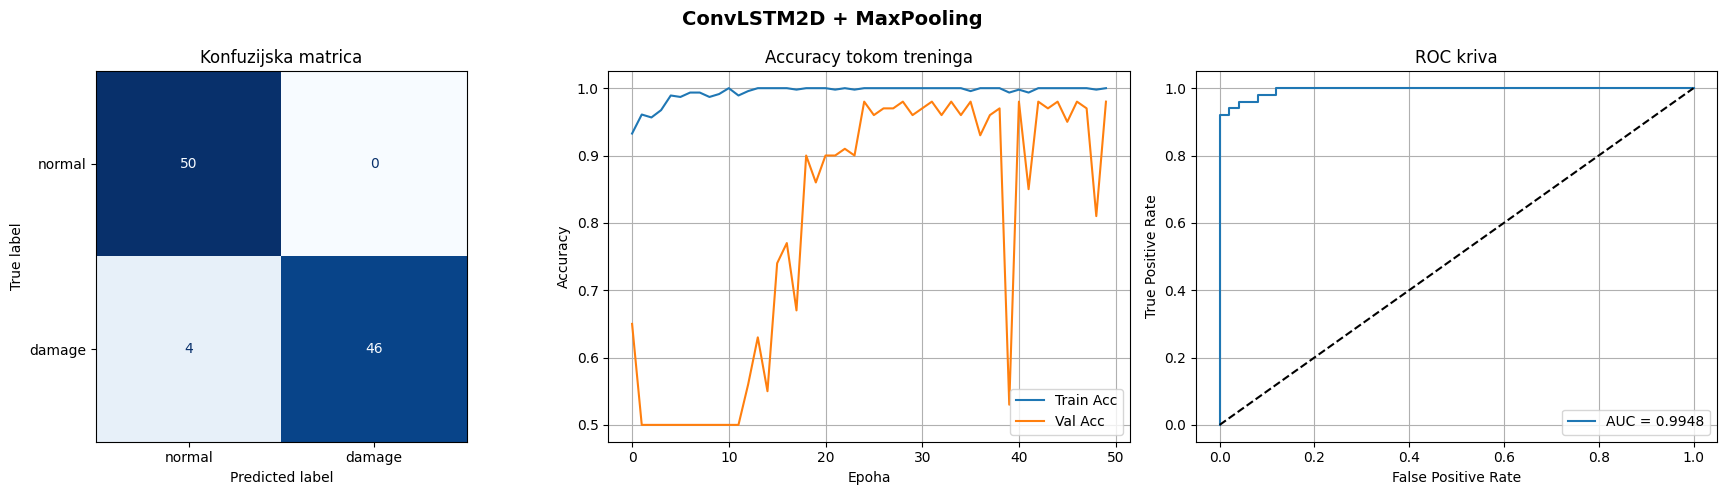

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ConvLSTM2D + MaxPooling", fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES_LIST)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title("Konfuzijska matrica")

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title("Accuracy tokom treninga")
axes[1].set_xlabel("Epoha")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_title("ROC kriva")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()